# Simulation Methodology

---Patient Modeling Workspace---

1. Contour Cell Layer (at the bottom of the cell flask).
2. Set an External ROI that extends from above the top of the medium to 8.06 cm below the isocentre (=snout position)
3. Contour an ROI 'Modulator' extending 6 mm upwards from the bottom of the external ROI. This is to model the 6 mm solid water in the high LET setup. 
4. Contour an ROI 'AirGap' between the 'Modulator' and the bottom of the solid water plate.

![alt text](<../LET calculation in setup from RS sim/ARCHIVED_Final RS sims (69 MeV)/Low LET/Patient Modelling.png>)

---Plan Design Workspace---

5. Set gantry angle to 180 degrees.
6. Set snout position to 8.25 cm (closest we can get to 8.06 due to safety margin, I've established in the calculation 'Does 0.13 cm snout position matter' that this matters little).
7. Copy the MUs from the treatment plan and enter for the beam. Ensure that the MU/spot is the same as in the treatment plan (this is more important than the total MU)

![alt text](<../LET calculation in setup from RS sim/ARCHIVED_Final RS sims (69 MeV)/Low LET/Plan Design.png>)

---Plan Optimisation Workspace---

8. Set up the spots (16.8x16.8 field with 0.8 spacing, yields 22x22 spots, energy 69 MeV) using the treatment plan parameters.
9. Run dose calculation including 'Calculate LET'

![alt text](<../LET calculation in setup from RS sim/ARCHIVED_Final RS sims (69 MeV)/Low LET/Plan Optimisation.png>)

---Plan Evaluation Workspace---

10. Used the LET export script to export the dose and LET data that I'm analysing here.

***For low LET***
The 'Solid Water Modulator' ROI gets a material override to 'Air'. (Step 4)
The beam gets no range shifter. (Step 6)

***For high LET***
The 'Solid Water Modulator' ROI gets a material override to 'Water'. (Step 4)
Add RS2 as range shifter to the beam. (Step 6)

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

In [2]:
def Calculate_BP_Positions(path_pos1, path_pos2, nominal_dose):
    #Calculate the dose and LET in different Bragg Peak Positions from the csv data that results from the LET export script in RayStation

    #Inputs
    #path_pos1 = path to the file for the low LET position
    #path_pos2 = path to the file for the high LET position
    #nominal_dose = int specifying the dose in the plan

    #Outputs
    #LET and dose map in the cell layer, for both positions
    #LET and dose difference maps between the two positions
    #Printed statistics


    ### PRE-PROCESSING ###############################################################################################
    data_pos1 = pd.read_csv(path_pos1)
    data_pos2 = pd.read_csv(path_pos2)


    ### PRINTING STATISTICS #########################################################################################
    print("----Proximal BP position data----")
    print("Mean dose: " + str(round(np.mean(data_pos1['Physical_dose']),2)) + " Gy")
    print("Max dose: " + str(round(np.max(data_pos1['Physical_dose']),2)) + " Gy")
    print("Min dose: " + str(round(np.min(data_pos1['Physical_dose']),2)) + " Gy")
    print("Mean LET: " + str(round(np.mean(data_pos1['LET_keV_per_um']),1)) + " keV/um")
    print("Max LET: " + str(round(np.max(data_pos1['LET_keV_per_um']),2)) + " keV/um")
    print("Min LET: " + str(round(np.min(data_pos1['LET_keV_per_um']),2)) + " keV/um")

    print("----Distal BP position data----")
    print("Mean dose: " + str(round(np.mean(data_pos2['Physical_dose']),2)) + " Gy")
    print("Max dose: " + str(round(np.max(data_pos2['Physical_dose']),2)) + " Gy")
    print("Min dose: " + str(round(np.min(data_pos2['Physical_dose']),2)) + " Gy")
    print("Mean LET: " + str(round(np.mean(data_pos2['LET_keV_per_um']),1)) + " keV/um")
    print("Max LET: " + str(round(np.max(data_pos2['LET_keV_per_um']),2)) + " keV/um")
    print("Min LET: " + str(round(np.min(data_pos2['LET_keV_per_um']),2)) + " keV/um")



    ### WRITE IMAGE ARRAY OF LET AND DOSE ############################################################################
    #Due to the fineness of the dose grid the cell layer also has multiple depth values, I'll map the middle one
    half = int(len(data_pos1['y_mm'].unique())/2)
    slice_pos1 = data_pos1[data_pos1['y_mm']==data_pos1['y_mm'].unique()[half]]
    slice_pos2 = data_pos2[data_pos2['y_mm']==data_pos2['y_mm'].unique()[half]]
    
    #Set up image array
    x_vals = np.sort(slice_pos1['x_mm'].unique())
    z_vals = np.sort(slice_pos1['z_mm'].unique())
    let_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    let_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    dose_pos1 = np.zeros([int(len(z_vals)), int(len(x_vals))])
    dose_pos2 = np.zeros([int(len(z_vals)), int(len(x_vals))])

    #Populate image array 1 with LET and dose values
    for i in slice_pos1.index.tolist():
        datapoint = slice_pos1.loc[i]
        x = datapoint.x_mm
        z = datapoint.z_mm
        let = datapoint.LET_keV_per_um
        dose = datapoint.Physical_dose

        x_index = np.where(x_vals == x)
        z_index = np.where(z_vals == z)

        let_pos1[z_index, x_index] = let
        dose_pos1[z_index, x_index] = dose

    #Populate image array 2 with let and dose values
    for i in slice_pos2.index.tolist():
        datapoint = slice_pos2.loc[i]
        x = datapoint.x_mm
        z = datapoint.z_mm
        let = datapoint.LET_keV_per_um
        dose = datapoint.Physical_dose

        x_index = np.where(x_vals == x)
        z_index = np.where(z_vals == z)

        let_pos2[z_index, x_index] = let
        dose_pos2[z_index, x_index] = dose

    # ### PLOTTING LET AND DOSE MAP ################################################################################
    # fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

    # plt.suptitle('LET maps for both BP positions, ' + str(nominal_dose) + ' mm')
    # data = ((let_pos1, let_pos2))
    # titles = (('LET map proximal', 'LET map distal'))
 
    # for col in range(2):
    #     ax = axes[col]
    #     ax.set_title(titles[col])
    #     pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=18)
    # fig.colorbar(pcm, ax=axes, shrink=0.6)


    # fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

    # plt.suptitle('Dose maps for both BP positions, ' + str(nominal_dose) + ' mm')
    # data = ((dose_pos1, dose_pos2))
    # titles = (('Dose map proximal', 'Dose map distal'))
 
    # for col in range(2):
    #     ax = axes[col]
    #     ax.set_title(titles[col])
    #     pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=2.5)
    # fig.colorbar(pcm, ax=axes, shrink=0.6)


    # ### PLOTTING THE DIFFERENCE MAP ##############################################################################
    # fig = plt.figure()
    # plt.suptitle('LET difference map, ' + str(nominal_dose) + ' mm')
    # plt.pcolormesh(let_pos2 - let_pos1, cmap='bwr', vmin=0, vmax=18)
    # plt.colorbar()

    # ### PLOTTING THE DIFFERENCE MAP ##############################################################################
    # fig = plt.figure()
    # plt.suptitle('Dose difference map, ' + str(nominal_dose) + ' mm')
    # plt.pcolormesh(dose_pos2 - dose_pos1, cmap='bwr', vmin=-1, vmax=1)
    # plt.colorbar()

    return dose_pos1, dose_pos2, let_pos1, let_pos2

# Results 69 MeV

The issue with the simulations is that the WET of the modulating solid water cannot exactly be matched (bc you're bound to slice thickness). 

Therefore I interpolate.

These results are for 6.15 mm water

In [3]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\ARCHIVED_Final RS sims (69 MeV)\Low LET\Final RS sim low LET 2 Gy.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\ARCHIVED_Final RS sims (69 MeV)\High LET\Final RS high LET 2 Gy (6.15 mm).csv"

dose_front, dose_615, let_front, let_615 = Calculate_BP_Positions(path_lowLET, path_highLET, 6.15)

----Proximal BP position data----
Mean dose: 1.97 Gy
Max dose: 2.02 Gy
Min dose: 1.93 Gy
Mean LET: 1.3 keV/um
Max LET: 1.38 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 2.18 Gy
Max dose: 4.66 Gy
Min dose: 0.3 Gy
Mean LET: 16.0 keV/um
Max LET: 18.8 keV/um
Min LET: 12.37 keV/um


And these results are for 7.03 mm water

In [4]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\ARCHIVED_Final RS sims (69 MeV)\Low LET\Final RS sim low LET 2 Gy.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\ARCHIVED_Final RS sims (69 MeV)\High LET\Final RS high LET 2 Gy (7.03 mm).csv"

dose_front, dose_703, let_front, let_703 = Calculate_BP_Positions(path_lowLET, path_highLET, 7.03)

----Proximal BP position data----
Mean dose: 1.97 Gy
Max dose: 2.02 Gy
Min dose: 1.93 Gy
Mean LET: 1.3 keV/um
Max LET: 1.38 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 0.49 Gy
Max dose: 2.14 Gy
Min dose: 0.09 Gy
Mean LET: 16.1 keV/um
Max LET: 19.7 keV/um
Min LET: 4.4 keV/um


In reality, we're talking 3*(2.11) = 6.33 mm 'water'.

Assuming linearity in LET and dose in the back of the BP, interpolate to find true values.

Actual dose: 1.83 Gy


Text(0.5, 1.0, 'Actual dose in high LET position, interpolation')

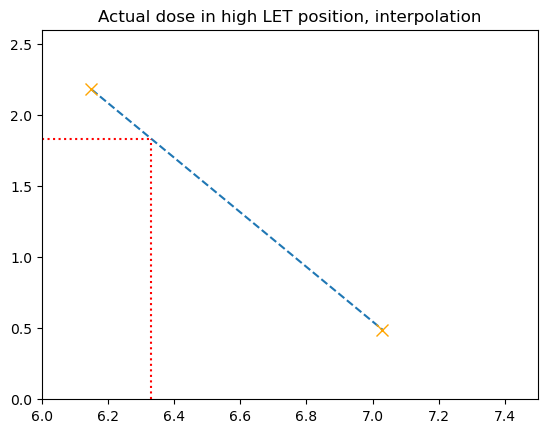

In [5]:
depth_1 = 6.15 #mm solid water
dose_1 = 2.18 #Gy
let_1 = 16.0 #keV/um

depth_2 = 7.03 #mm solid water
dose_2 = 0.49 #Gy
let_2 = 16.1 #keV/um

actual_dose = np.interp(6.33,[depth_1, depth_2], [dose_1, dose_2])

print('Actual dose: ' + str(round(actual_dose, 2)) + ' Gy')

plt.plot([depth_1, depth_2], [dose_1, dose_2], linestyle='dashed', marker='x', markeredgecolor='orange', markersize=8)
plt.hlines(actual_dose, 6, 6.33, linestyles='dotted', colors='red')
plt.vlines(6.33, 0, actual_dose, linestyles='dotted', colors='red')
plt.xlim([6, 7.5])
plt.ylim([0, 2.6])
plt.title('Actual dose in high LET position, interpolation')

Actual LET: 16.0 keV/um


Text(0.5, 1.0, 'Actual LET in high LET position, interpolation')

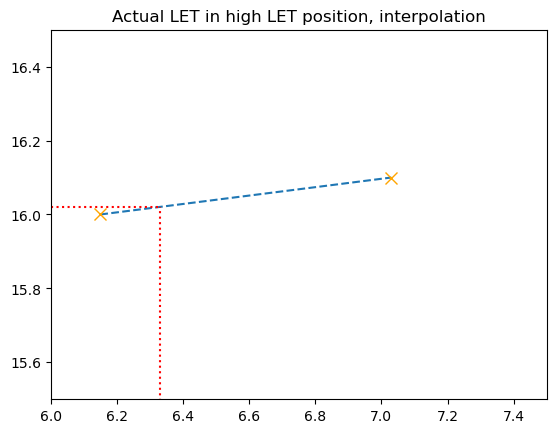

In [6]:
actual_let = np.interp(6.33, [depth_1, depth_2], [let_1, let_2])

print('Actual LET: ' + str(round(actual_let, 1)) + ' keV/um')

plt.plot([depth_1, depth_2], [let_1, let_2], linestyle='dashed', marker='x', markeredgecolor='orange', markersize=8)
plt.hlines(actual_let, 6, 6.33, linestyles='dotted', colors='red')
plt.vlines(6.33, 0, actual_let, linestyles='dotted', colors='red')
plt.xlim([6, 7.5])
plt.ylim([15.5, 16.5])
plt.title('Actual LET in high LET position, interpolation')

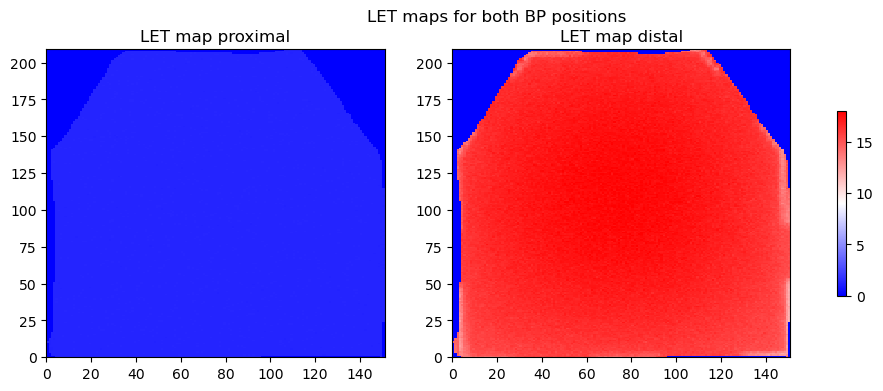

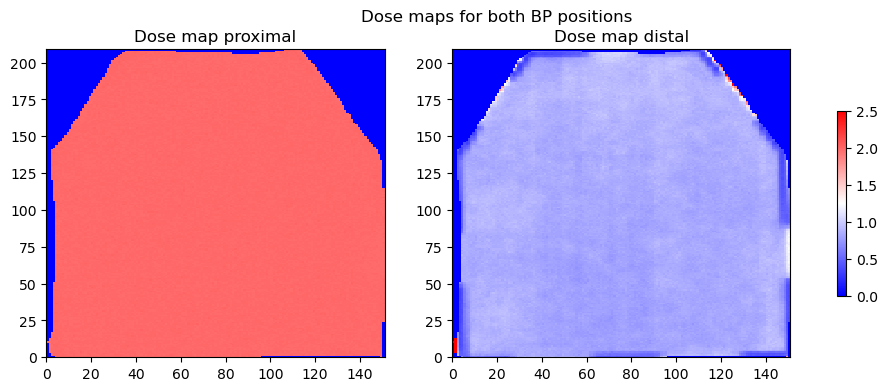

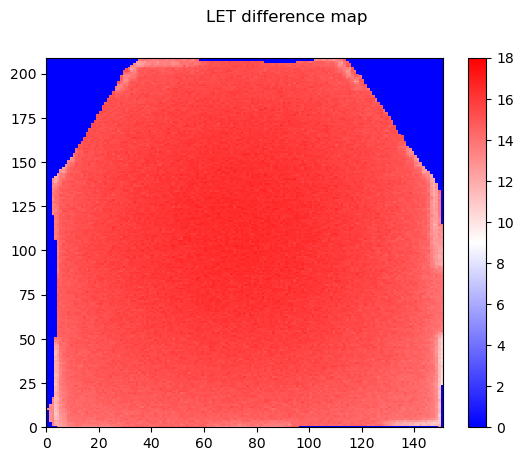

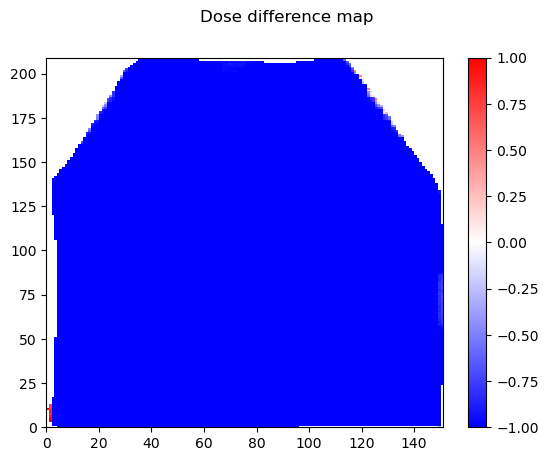

In [7]:
dose_diff = dose_703 - dose_615
let_diff = let_703 - let_615

frac = (6.33 - 6.15)/(7.03 - 6.15)

dose_back = dose_615 + frac*dose_diff
let_back = let_615 + frac*let_diff

### PLOTTING LET AND DOSE MAP ################################################################################
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('LET maps for both BP positions')
data = ((let_front, let_back))
titles = (('LET map proximal', 'LET map distal'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=18)
fig.colorbar(pcm, ax=axes, shrink=0.6)


fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('Dose maps for both BP positions')
data = ((dose_front, dose_back))
titles = (('Dose map proximal', 'Dose map distal'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=2.5)
fig.colorbar(pcm, ax=axes, shrink=0.6)


### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('LET difference map')
plt.pcolormesh(let_back - let_front, cmap='bwr', vmin=0, vmax=18)
plt.colorbar()

### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('Dose difference map')
plt.pcolormesh(dose_back - dose_front, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

# Results 69.87 MeV

These results are for 7.03 mm water

In [8]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\Low LET\Full plan match low LET.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\High LET\Full plan match high LET (7.03 mm).csv"

dose_front, dose_703, let_front, let_703 = Calculate_BP_Positions(path_lowLET, path_highLET, 7.03)

----Proximal BP position data----
Mean dose: 1.99 Gy
Max dose: 2.04 Gy
Min dose: 1.94 Gy
Mean LET: 1.3 keV/um
Max LET: 1.37 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 2.54 Gy
Max dose: 5.02 Gy
Min dose: 0.43 Gy
Mean LET: 15.4 keV/um
Max LET: 17.99 keV/um
Min LET: 12.11 keV/um


And these results are for 7.91 mm water

In [9]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\Low LET\Full plan match low LET.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\High LET\Full plan match high LET (7.91 mm).csv"

dose_front, dose_791, let_front, let_791 = Calculate_BP_Positions(path_lowLET, path_highLET, 7.91)

----Proximal BP position data----
Mean dose: 1.99 Gy
Max dose: 2.04 Gy
Min dose: 1.94 Gy
Mean LET: 1.3 keV/um
Max LET: 1.37 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 1.05 Gy
Max dose: 3.17 Gy
Min dose: 0.13 Gy
Mean LET: 16.9 keV/um
Max LET: 19.33 keV/um
Min LET: 6.57 keV/um


In reality, we're talking 3*(2.11) + 1.05 = 7.38 mm 'water'.

Assuming linearity in LET and dose in the back of the BP, interpolate to find true values.

Actual dose: 1.95 Gy


Text(0.5, 1.0, 'Actual dose in high LET position, interpolation')

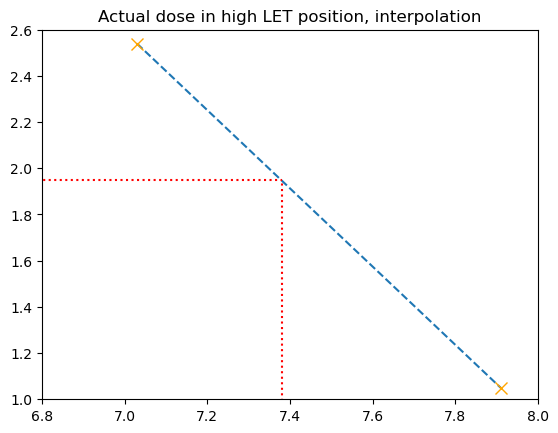

In [10]:
depth_1 = 7.03 #mm solid water
dose_1 = 2.54 #Gy
let_1 = 15.4 #keV/um

depth_2 = 7.91 #mm solid water
dose_2 = 1.05 #Gy
let_2 = 16.9 #keV/um

actual_dose = np.interp(7.38,[depth_1, depth_2], [dose_1, dose_2])

print('Actual dose: ' + str(round(actual_dose, 2)) + ' Gy')

plt.plot([depth_1, depth_2], [dose_1, dose_2], linestyle='dashed', marker='x', markeredgecolor='orange', markersize=8)
plt.hlines(actual_dose, 6, 7.38, linestyles='dotted', colors='red')
plt.vlines(7.38, 0, actual_dose, linestyles='dotted', colors='red')
plt.xlim([6.8, 8])
plt.ylim([1, 2.6])
plt.title('Actual dose in high LET position, interpolation')

Actual let: 16.0 keV/um


Text(0.5, 1.0, 'Actual LET in high LET position, interpolation')

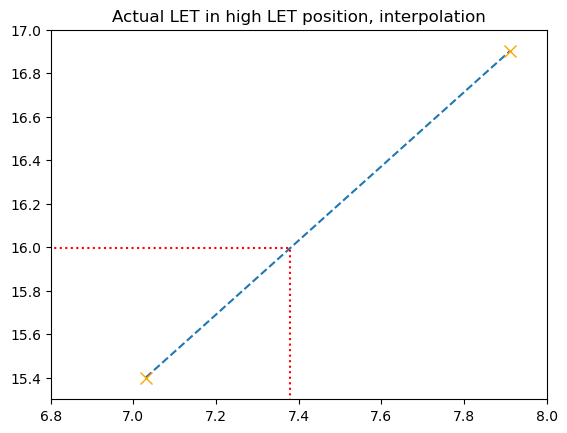

In [11]:
actual_let = np.interp(7.38, [depth_1, depth_2], [let_1, let_2])

print('Actual let: ' + str(round(actual_let, 1)) + ' keV/um')

plt.plot([depth_1, depth_2], [let_1, let_2], linestyle='dashed', marker='x', markeredgecolor='orange', markersize=8)
plt.hlines(actual_let, 6, 7.38, linestyles='dotted', colors='red')
plt.vlines(7.38, 0, actual_let, linestyles='dotted', colors='red')
plt.xlim([6.8, 8])
plt.ylim([15.3, 17])
plt.title('Actual LET in high LET position, interpolation')

Those were the mean values, let's also make interpolated maps.

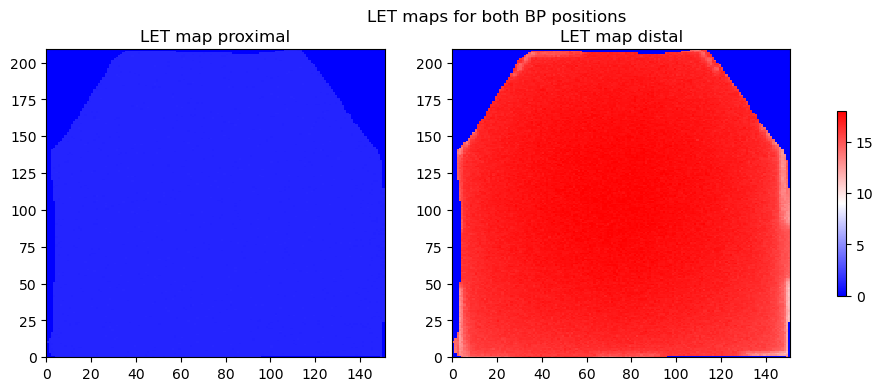

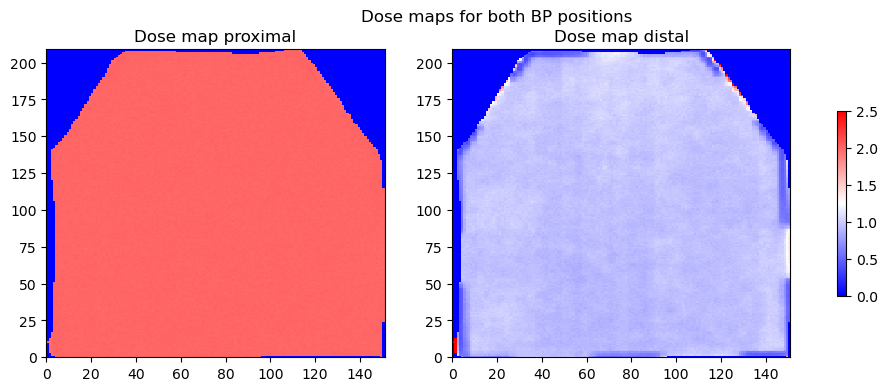

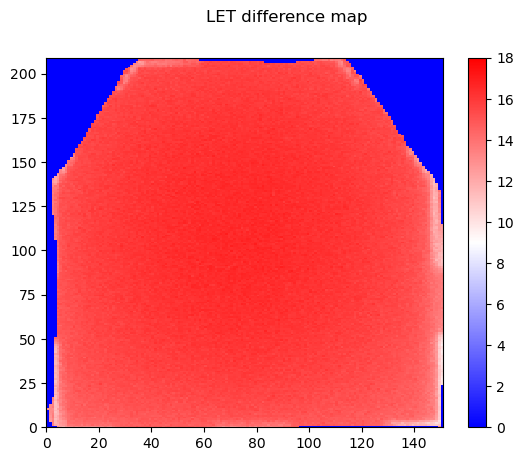

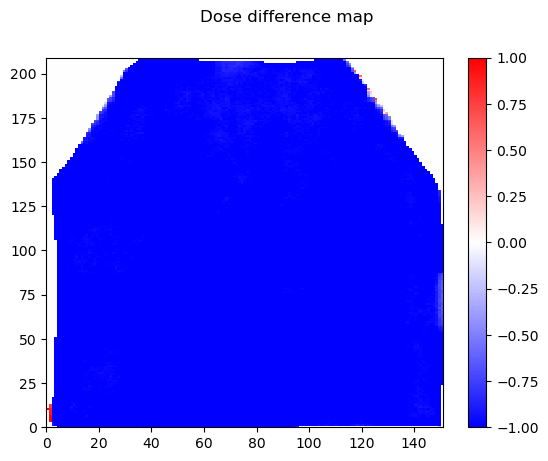

In [12]:
dose_diff = dose_791 - dose_703
let_diff = let_791 - let_703

frac = (7.38 - 7.03)/(7.91 - 7.03)

dose_back = dose_703 + frac*dose_diff
let_back = let_703 + frac*let_diff

### PLOTTING LET AND DOSE MAP ################################################################################
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('LET maps for both BP positions')
data = ((let_front, let_back))
titles = (('LET map proximal', 'LET map distal'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=18)
fig.colorbar(pcm, ax=axes, shrink=0.6)


fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('Dose maps for both BP positions')
data = ((dose_front, dose_back))
titles = (('Dose map proximal', 'Dose map distal'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=2.5)
fig.colorbar(pcm, ax=axes, shrink=0.6)


### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('LET difference map')
plt.pcolormesh(let_back - let_front, cmap='bwr', vmin=0, vmax=18)
plt.colorbar()

### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('Dose difference map')
plt.pcolormesh(dose_back - dose_front, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

## Also for mid LET

No need to interpolate, could match amount of solid water perfectly (yay!)

In [16]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\Low LET\Full plan match low LET.csv"
path_midLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\Mid LET\69.87 MeV mid LET.csv"

dose_front, dose_mid, let_front, let_mid = Calculate_BP_Positions(path_lowLET, path_midLET, 7.91)

----Proximal BP position data----
Mean dose: 1.99 Gy
Max dose: 2.04 Gy
Min dose: 1.94 Gy
Mean LET: 1.3 keV/um
Max LET: 1.37 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 1.9 Gy
Max dose: 2.13 Gy
Min dose: 1.28 Gy
Mean LET: 10.2 keV/um
Max LET: 12.84 keV/um
Min LET: 7.01 keV/um


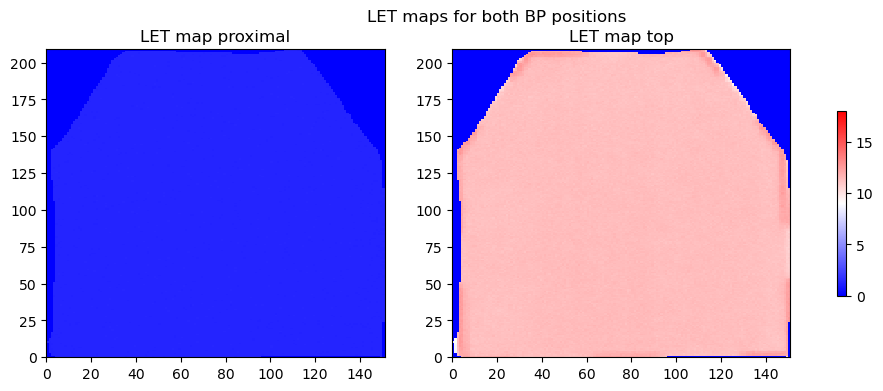

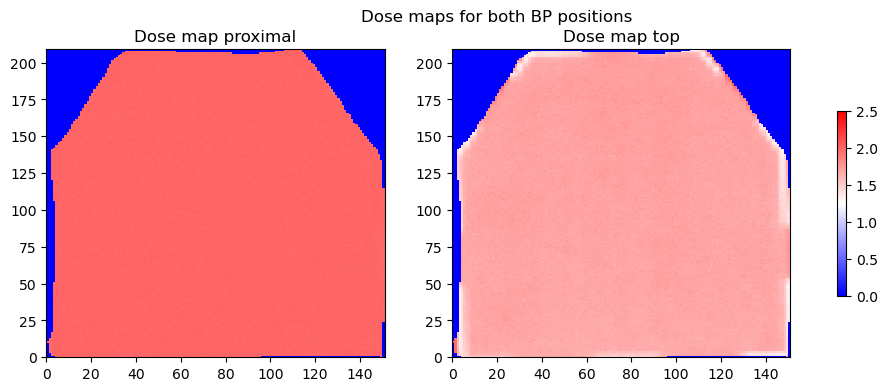

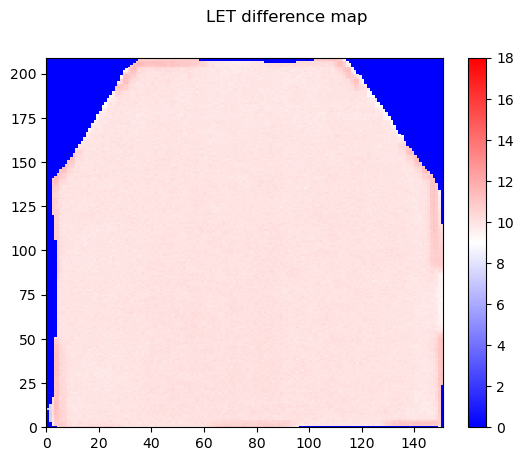

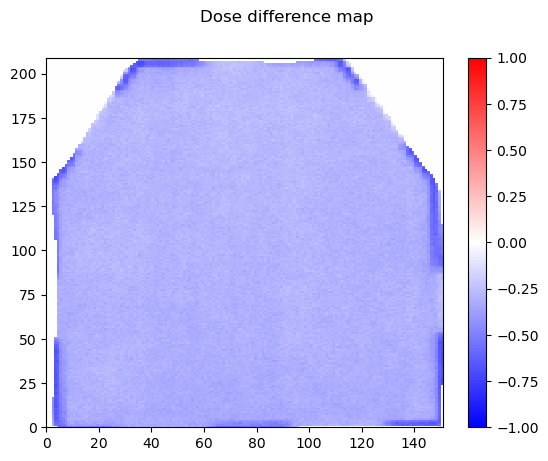

In [17]:
### PLOTTING LET AND DOSE MAP ################################################################################
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('LET maps for both BP positions')
data = ((let_front, let_mid))
titles = (('LET map proximal', 'LET map top'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=18)
fig.colorbar(pcm, ax=axes, shrink=0.6)


fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))

plt.suptitle('Dose maps for both BP positions')
data = ((dose_front, dose_mid))
titles = (('Dose map proximal', 'Dose map top'))
 
for col in range(2):
    ax = axes[col]
    ax.set_title(titles[col])
    pcm = ax.pcolormesh(data[col], cmap='bwr', vmin=0, vmax=2.5)
fig.colorbar(pcm, ax=axes, shrink=0.6)


### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('LET difference map')
plt.pcolormesh(let_mid - let_front, cmap='bwr', vmin=0, vmax=18)
plt.colorbar()

### PLOTTING THE DIFFERENCE MAP ##############################################################################
fig = plt.figure()
plt.suptitle('Dose difference map')
plt.pcolormesh(dose_mid - dose_front, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

The same, but with a different dose grid, does match RS fully.

Dose grid matters!

In [14]:
path_lowLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\Low LET\Final RS low LET 69.87 MeV.csv"
path_highLET = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\LET calculation in setup from RS sim\Final RS sims 69.87 MeV\High LET\Final RS high LET 69.87 MeV (7.91 mm) diff dose grid.csv"

Calculate_BP_Positions(path_lowLET, path_highLET, 7.91)

----Proximal BP position data----
Mean dose: 1.96 Gy
Max dose: 2.01 Gy
Min dose: 1.92 Gy
Mean LET: 1.3 keV/um
Max LET: 1.4 keV/um
Min LET: 1.22 keV/um
----Distal BP position data----
Mean dose: 1.25 Gy
Max dose: 3.69 Gy
Min dose: 0.21 Gy
Mean LET: 16.6 keV/um
Max LET: 19.35 keV/um
Min LET: 7.53 keV/um


IndexError: index 2 is out of bounds for axis 0 with size 2